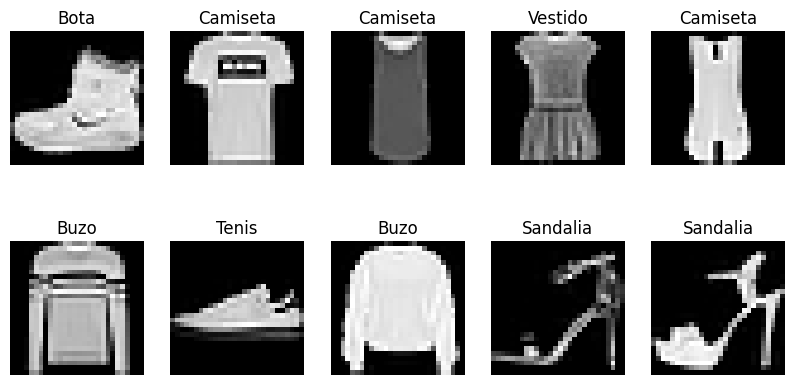

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np


# ==========================
# 1. Cargar y visualizar datos
# ==========================

(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

# Normalización (0 a 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Cambiar dimensiones para CNN (n, 28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Mostrar algunas imágenes
class_names = ['Camiseta', 'Pantalón', 'Buzo', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Tenis', 'Bolso', 'Bota']

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [2]:
# ==========================
# 2. Construcción del modelo (LeNet-5)
# ==========================
model = models.Sequential([
    layers.Conv2D(6, (5, 5), activation='relu', input_shape=(28, 28, 1), padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(16, (5, 5), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(120, activation='relu'),
    layers.Dense(84, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.summary()

c:\Users\juans\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7638 - loss: 0.6498 - val_accuracy: 0.8320 - val_loss: 0.4675
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8536 - loss: 0.4067 - val_accuracy: 0.8576 - val_loss: 0.3977
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8736 - loss: 0.3518 - val_accuracy: 0.8724 - val_loss: 0.3525
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8844 - loss: 0.3199 - val_accuracy: 0.8779 - val_loss: 0.3409
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8918 - loss: 0.2981 - val_accuracy: 0.8840 - val_loss: 0.3223
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8988 - loss: 0.2790 - val_accuracy: 0.8834 - val_loss: 0.3307
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9043 - loss: 0.2650 - val_accuracy: 0.8914 - val_loss: 0.3026
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9075 - loss: 0.2542 - val_accuracy: 0.

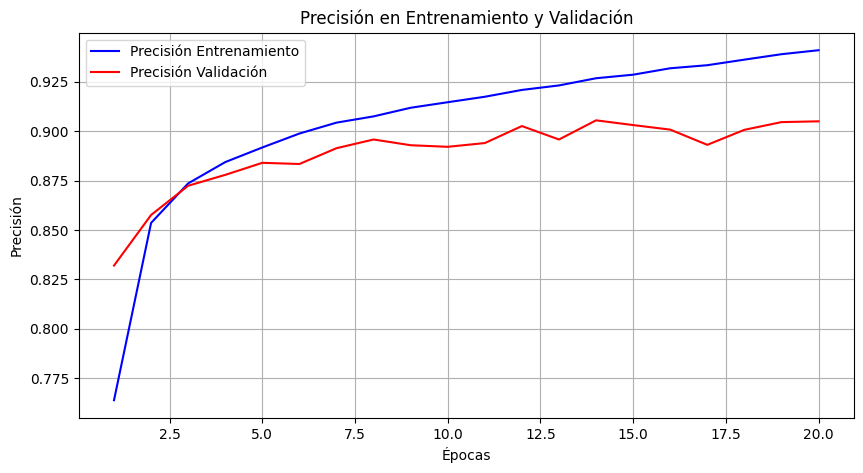

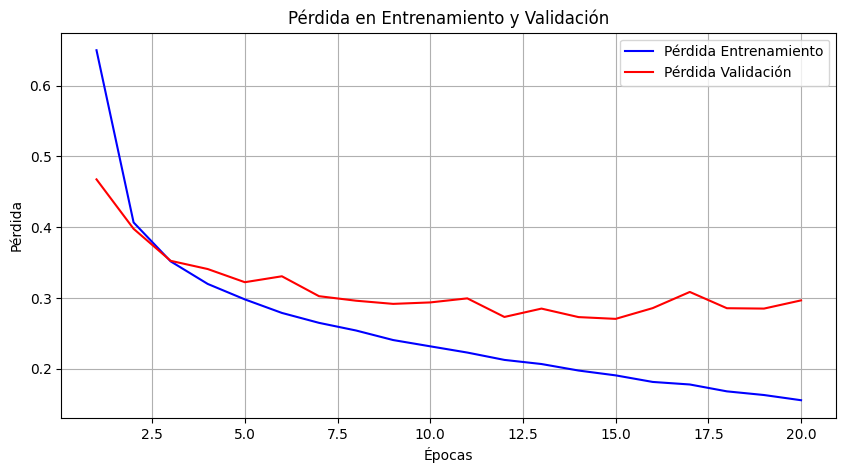

In [3]:
# ==========================
# 3. Entrenamiento del modelo
# ==========================

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=20, batch_size=128,
                    validation_data=(x_test, y_test))

# Guardamos el historial
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# ---- Gráfica de Precisión ----
plt.figure(figsize=(10, 5))
plt.plot(epochs, acc, 'b-', label='Precisión Entrenamiento')
plt.plot(epochs, val_acc, 'r-', label='Precisión Validación')
plt.title('Precisión en Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)
plt.show()

# ---- Gráfica de Pérdida ----
plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, 'b-', label='Pérdida Entrenamiento')
plt.plot(epochs, val_loss, 'r-', label='Pérdida Validación')
plt.title('Pérdida en Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()


In [4]:
# ==========================
# 4. Evaluación del modelo
# ==========================
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n🔍 Precisión en test: {test_acc*100:.2f}%")


313/313 - 0s - 1ms/step - accuracy: 0.9050 - loss: 0.2967

🔍 Precisión en test: 90.50%


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


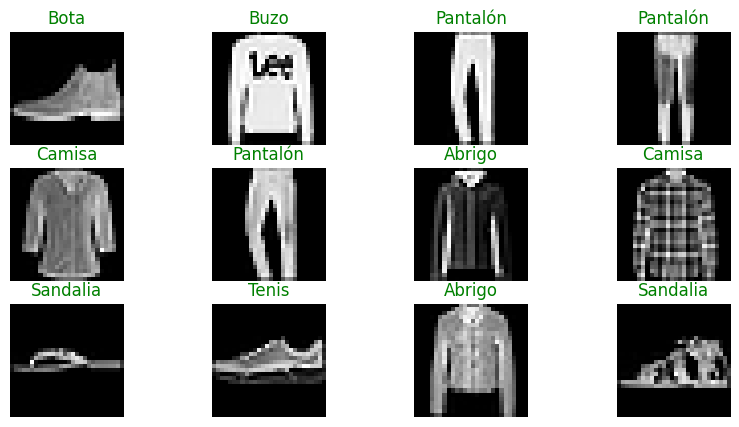

In [5]:
# ==========================
# 5. Predicciones
# ==========================
predictions = model.predict(x_test)
pred_labels = np.argmax(predictions, axis=1)

# Mostrar algunas predicciones
plt.figure(figsize=(10, 5))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if pred_labels[i] == y_test[i] else 'red'
    plt.title(f"{class_names[pred_labels[i]]}", color=color)
    plt.axis('off')
plt.show()